# Generating & Validating the Synthetic Data

The notebook is organized into two parts. **Part 1** generates the panel: accounts, macroeconomic conditions, trips, prices, customer behavior, and revenue. **Part 2** validates it, confirming the panel is usable and locating the reduce/unchanged label boundary. A fully synthetic, 50,000-account panel was built for the international roaming pricing case study, including accounts, macroeconomic conditions, trips, prices, customer behavior, and revenue. The data was validated before any downstream modeling was performed. No proprietary data was used anywhere in this project; every value was generated from parameters chosen to produce plausible behavior.

The data was generated from an explicit behavioral process, so each account's underlying price sensitivity and travel propensity was known by construction rather than estimated. This made it possible to evaluate downstream model performance against the parameters that actually generated the data, providing a direct test of parameter recovery rather than relying solely on predictive accuracy. In addition, randomness was layered intentionally, with account heterogeneity, a shared macro path, trip-level draws, and choice noise each contributing separately. Concentrating noise in a single component can produce models that perform unrealistically well in testing and understate the challenges they may face on real-world data.


---

## Part 1 · Generating the Synthetic Data

This part runs in seven steps, each depending only on the ones above it.

1. **Accounts**: structure (lines, tenure, plan, business flag) and two latent traits: travel propensity and price sensitivity.
2. **Macro path**: 24 months of an AR(1) economic index; converted to a travel-volume multiplier applied to everyone at once.
3. **Trips**: Poisson draws per account-month, scaled by propensity × seasonality × macro. Each trip gets a destination, a party size, and a duration.
4. **Price faced**: the historical price variation the model will eventually learn from. Without variation there is nothing to estimate, so this is generated explicitly rather than assumed.
5. **Behavioral state**: a multinomial logit over the five states, driven by the account's latent sensitivity and the price it faced.
6. **Magnitude**: for the two states that need sizing (reduce, increase), how many lines and days were actually bought.
7. **Revenue**: the pricing identity applied to the realized lines and days.

Sanity checks and the ground-truth export follow as steps 8–9, then Part 2 picks up directly from what's in memory.


In [1]:
# Load Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


In [2]:
# Synthteic Data Parameters
RNG = np.random.default_rng(20260820)
DATA = Path('synthetic')
DATA.mkdir(parents=True, exist_ok = True)

N_ACCOUNTS = 50_000
N_MONTHS = 24

# Product Pricing
PRICE_FIRST_LINE = 10.0
PRICE_ADDL_LINE = 5.0

pd.set_option('display.width', 140)
pd.set_option('display.max_columns', 40)

SURFACE = '#fcfcfb'
INK = '#0b0b0b'
MUTED = '#898781'
GRID = '#e1e0d9'
BASELINE = '#c3c2b7'
ACCENT = '#2a78d6'
ACCENT2 = '#eb6834'
RED = '#e34948'

plt.rcParams.update({
    'figure.dpi': 110,
    'figure.facecolor': SURFACE,
    'axes.facecolor': SURFACE,
    'savefig.facecolor': SURFACE,
    'axes.edgecolor': BASELINE,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.color': GRID,
    'grid.linewidth': 0.8,
    'grid.linestyle': '-',
    'axes.axisbelow': True,
    'font.size': 9,
    'text.color': INK,
    'axes.labelcolor': INK,
    'xtick.color': MUTED,
    'ytick.color': MUTED,
})


## 1 · Accounts

**Purpose:** Generates the 50,000 synthetic accounts, including two hidden traits, `travel_propensity` and `price_sensitivity`, that drive everything downstream. Sensitivity is deliberately not fully predictable from the account's other fields, so later notebooks can be scored on whether they actually recover it rather than just fitting the data.

**Design Notes:**

- `travel_propensity`: expected international trips per month; lognormal, so a minority of accounts travel far more than the median
- `price_sensitivity`: reaction to a price change; negative, nearer zero = less sensitive
  1. Built from `is_business`, plan tier, and `travel_propensity` (the other latent trait), plus an unexplained residual
  2. Residual keeps it from being fully determined by the other fields

In [3]:

def make_accounts(n, rng):
    is_business = rng.random(n) < 0.22

    # Business Accounts Skew to More Lines
    lines = np.where(
        is_business,
        rng.choice([1, 2, 3, 4, 5], size = n, p = [0.15, 0.20, 0.25, 0.22, 0.18]),
        rng.choice([1, 2, 3, 4, 5], size = n, p = [0.38, 0.31, 0.17, 0.09, 0.05]),
    )

    tenure_months = rng.integers(1, 145, size=n)
    plan_tier = rng.choice(['value', 'standard', 'premium'], size = n, p = [0.30, 0.45, 0.25])
    premium = (plan_tier == 'premium').astype(float)

    # Travel Propensity: Trips per Month (lognormal)
    log_prop = (
        -3.60
        + 1.55 * is_business
        + 0.35 * premium
        + 0.004 * (tenure_months - 72) / 12
        + rng.normal(0, 0.95, size = n)
    )
    travel_propensity = np.exp(log_prop)

    # Negative: nearer zero = less sensitive
    price_sensitivity = (
        -1.60
        + 0.95 * is_business
        + 0.30 * premium
        + 0.08 * np.log1p(travel_propensity * 12)
        + rng.normal(0, 0.40, size = n)
    )
    price_sensitivity = np.clip(price_sensitivity, -3.0, -0.05)

    return pd.DataFrame({
        'account_id': np.arange(n),
        'is_business': is_business,
        'lines_on_account': lines,
        'tenure_months': tenure_months,
        'plan_tier': plan_tier,
        'travel_propensity': travel_propensity,
        'price_sensitivity': price_sensitivity,
    })

accounts = make_accounts(N_ACCOUNTS, RNG)
accounts.head()


,account_id,is_business,lines_on_account,tenure_months,plan_tier,travel_propensity,price_sensitivity
0,0,False,2,72,premium,0.008166,-0.817886
1,1,True,5,76,premium,0.615436,-0.265488
2,2,False,2,117,value,0.027803,-1.333017
3,3,False,2,97,standard,0.022454,-1.928163
4,4,True,1,2,premium,0.144453,-0.819382


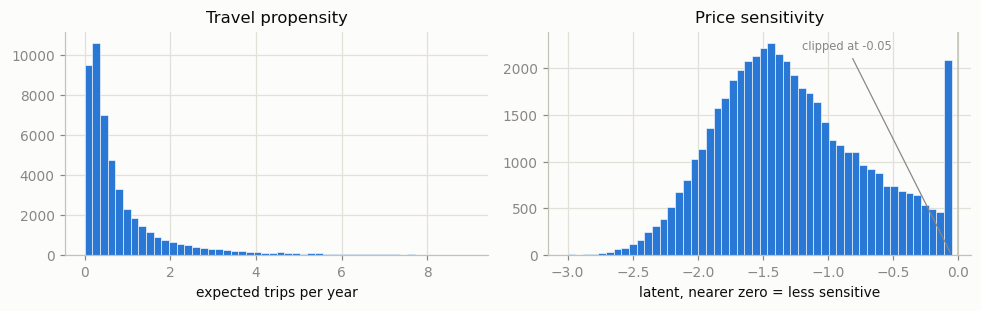

In [4]:

fig, axes = plt.subplots(1, 2, figsize = (9, 2.9))

prop_years = accounts['travel_propensity'] * 12
q99 = prop_years.quantile(0.99)
axes[0].hist(prop_years, bins = 50, range = (0, q99), color = ACCENT,
             edgecolor = SURFACE, linewidth = 0.4)
axes[0].set_title('Travel propensity')
axes[0].set_xlabel('expected trips per year')

axes[1].hist(accounts['price_sensitivity'], bins = 50, color = ACCENT,
             edgecolor = SURFACE, linewidth = 0.4)
axes[1].axvline(0, color = BASELINE, linewidth = 1)
axes[1].set_title('Price sensitivity')
axes[1].set_xlabel('latent, nearer zero = less sensitive')

# Spike at -0.05 is real: the generator clips price_sensitivity there.
axes[1].annotate('clipped at -0.05', xy=(-0.05, 0), xycoords=('data', 'axes fraction'),
                  xytext=(0.60, 0.92), textcoords='axes fraction',
                  fontsize=7.5, color=MUTED, ha='left',
                  arrowprops=dict(arrowstyle='-', color=MUTED, lw=0.8))

plt.tight_layout()
plt.show()


## 2 · Macro Path

**Purpose:** Builds a shared economic cycle that scales every account's trip volume by the same monthly draw, so account outcomes are correlated and the later Monte Carlo simulation reports an honest revenue spread instead of overstated confidence.

**Design Notes:**

- AR(1) index for economic expansion and contraction, converted to a travel-volume multiplier
- Seasonality: data-derived, not assumed
  1. Source: U.S. Department of Commerce, International Trade Administration, I-92 program ([trade.gov/us-international-air-travel-statistics-i-92-data](https://www.trade.gov/us-international-air-travel-statistics-i-92-data))
  2. Population: U.S. Citizen Originating passengers
  3. Years: 2019, 2022-2025 (2020-2021 excluded: COVID collapse/recovery; 2026 excluded: partial year)
  4. Regions: Caribbean, South America, Europe, Central America, Africa, Asia, Oceania, Mideast
  5. Canada & Mexico excluded: international roaming does not apply to either

In [5]:
# Seasonal index from actual U.S. outbound air travel (U.S. Citizen Originating),
# not assumed. Source: US ITA I-92 program, trade.gov/us-international-air-travel-statistics-i-92-data
# 2020-2021 excluded (COVID collapse/recovery); 2026 excluded (partial year).

i92 = pd.read_csv('reference/us_i92_air_travel.csv')
i92_clean = i92[~i92['Year'].isin([2020, 2021, 2026])]
SEASONALITY_INDEX = (i92_clean.groupby('Month Number')['U.S. Citizen Originating'].mean()
                      .pipe(lambda s: s / s.mean()).to_numpy())
print('Seasonality index by month (Jan..Dec):')
print(np.round(SEASONALITY_INDEX, 3))


def make_macro(n_months, rng, phi=0.85, sigma=0.35, gamma=0.55):
    '''AR(1) economic index -> travel volume multiplier.

    phi   persistence; gamma how strongly the economy moves travel.
    '''
    idx = np.zeros(n_months)
    for t in range(1, n_months):
        idx[t] = phi * idx[t - 1] + rng.normal(0, sigma)

    month = np.arange(n_months)
    seasonality = SEASONALITY_INDEX[month % 12]

    return pd.DataFrame({
        'month': month,
        'macro_index': idx,
        'seasonality': seasonality,
        'travel_multiplier': np.exp(gamma * idx) * seasonality,
    })

macro = make_macro(N_MONTHS, RNG)
macro.head()


Seasonality index by month (Jan..Dec):
[0.7   0.706 0.986 0.933 1.117 1.373 1.289 1.065 0.975 0.911 0.87  1.076]


,month,macro_index,seasonality,travel_multiplier
0,0,0.000000,0.699788,0.699788
1,1,-0.035610,0.706191,0.692494
2,2,-0.475274,0.985865,0.759089
3,3,-0.500878,0.932844,0.708220
4,4,-0.701075,1.117243,0.759780


/var/folders/rj/lg_9h2v52pnckdkdmwvvw3xr0000gn/T/ipykernel_33887/1669374638.py:15: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


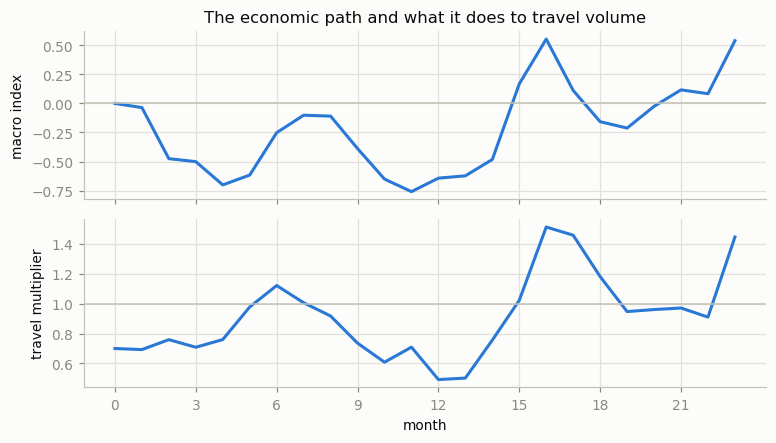

In [6]:

fig, axes = plt.subplots(2, 1, figsize=(8, 4.2), sharex=True,
                         gridspec_kw={'height_ratios': [1, 1], 'hspace': 0.12})

axes[0].plot(macro['month'], macro['macro_index'], color=ACCENT, linewidth=2)
axes[0].axhline(0, color=BASELINE, linewidth=1)
axes[0].set_ylabel('macro index')
axes[0].set_title('The economic path and what it does to travel volume')

axes[1].plot(macro['month'], macro['travel_multiplier'], color=ACCENT, linewidth=2)
axes[1].axhline(1.0, color=BASELINE, linewidth=1)
axes[1].set_ylabel('travel multiplier')
axes[1].set_xlabel('month')
axes[1].set_xticks(range(0, N_MONTHS, 3))

plt.tight_layout()
plt.show()


## 3 · Trips

**Purpose:** Draws each account's trips for the month via a Poisson process, attaching a destination, party size, and duration to each one.

**Design Notes:**

- Destination proxies substitute ease, not just geography
  1. Mature eSIM coverage → a real alternative to the pass
  2. Caps how far price can move, regardless of elasticity

In [7]:

REGIONS = ['europe', 'latam', 'apac', 'canada', 'other']
REGION_P = [0.34, 0.22, 0.18, 0.16, 0.10]

# Higher = easier to substitute the pass with eSIM / local SIM / Wi-Fi
SUBSTITUTE_EASE = {'europe': 0.85, 'latam': 0.55, 'apac': 0.70, 'canada': 0.40, 'other': 0.45}


def make_trips(accounts, macro, rng):
    prop = accounts['travel_propensity'].to_numpy()[:, None]      # (n, 1)
    mult = macro['travel_multiplier'].to_numpy()[None, :]         # (1, m)

    counts = rng.poisson(prop * mult)                             # (n, m)
    acct_idx, month_idx = np.nonzero(counts)
    reps = counts[acct_idx, month_idx]

    account_id = np.repeat(accounts['account_id'].to_numpy()[acct_idx], reps)
    month = np.repeat(month_idx, reps)
    n_trips = len(account_id)

    lines_available = accounts.set_index('account_id').loc[account_id, 'lines_on_account'].to_numpy()
    is_business = accounts.set_index('account_id').loc[account_id, 'is_business'].to_numpy()

    # Business trips are usually solo; leisure trips bring the household
    solo_p = np.where(is_business, 0.82, 0.32)
    solo = rng.random(n_trips) < solo_p
    lines_traveling = np.where(
        solo,
        1,
        1 + rng.binomial(np.maximum(lines_available - 1, 0), 0.75),
    )

    region = rng.choice(REGIONS, size=n_trips, p=REGION_P)

    # Duration: business trips shorter and tighter, leisure longer and more variable
    days = np.where(
        is_business,
        rng.lognormal(1.35, 0.40, size=n_trips),
        rng.lognormal(1.80, 0.60, size=n_trips),
    )
    days_traveled = np.clip(np.round(days), 1, 30).astype(int)

    return pd.DataFrame({
        'trip_id': np.arange(n_trips),
        'account_id': account_id,
        'month': month,
        'region': region,
        'lines_traveling': lines_traveling.astype(int),
        'days_traveled': days_traveled,
        'substitute_ease': [SUBSTITUTE_EASE[r] for r in region],
    })


trips = make_trips(accounts, macro, RNG)
print(f'{len(trips):,} trips across {trips.account_id.nunique():,} accounts')
trips.head()


94,579 trips across 29,406 accounts


,trip_id,account_id,month,region,lines_traveling,days_traveled,substitute_ease
0,0,1,0,apac,1,2,0.70
1,1,1,5,europe,1,3,0.85
2,2,1,5,other,1,4,0.45
3,3,1,8,other,1,4,0.45
4,4,1,8,other,3,4,0.45


## 4 · Price Faced

**Purpose:** Assigns each trip the price it actually faced, engineered with deliberate variation and confounding, so a price response can be estimated at all and the modeling notebook has a real confounding problem to demonstrate handling.

**Design Notes:**

- Variation generated three ways
  1. Market-level test in some regions
  2. Promotional window
  3. Small account-level pricing drift
- ~1/3 of trips face a non-standard rate
- Multiplier deliberately correlated with region and period, not random: a naive fit would attribute region/traveler differences to price

In [8]:

def assign_price(trips, rng):
    n = len(trips)
    mult = np.ones(n)

    # (a) Market test: two regions carried a higher rate for months 8-15
    in_test = trips['region'].isin(['europe', 'apac']).to_numpy() & trips['month'].between(8, 15).to_numpy()
    mult = np.where(in_test, rng.choice([1.10, 1.20], size=n, p=[0.5, 0.5]), mult)

    # (b) Promotional window: a discount in the shoulder season
    in_promo = trips['month'].isin([4, 5, 16, 17]).to_numpy() & (rng.random(n) < 0.55)
    mult = np.where(in_promo & ~in_test, rng.choice([0.90, 0.95], size=n, p=[0.6, 0.4]), mult)

    # (c) Residual drift so the variation is not purely two clean blocks
    drift = (rng.random(n) < 0.10)
    mult = np.where(drift & ~in_test & ~in_promo, rng.choice([0.95, 1.10], size=n), mult)

    out = trips.copy()
    out['price_multiplier'] = mult
    out['price_first_line'] = PRICE_FIRST_LINE * mult
    out['price_addl_line'] = PRICE_ADDL_LINE * mult
    return out


trips = assign_price(trips, RNG)
print(trips['price_multiplier'].value_counts(normalize=True).sort_index().round(3))


price_multiplier
0.90    0.071
0.95    0.085
1.00    0.668
1.10    0.107
1.20    0.069
Name: proportion, dtype: float64


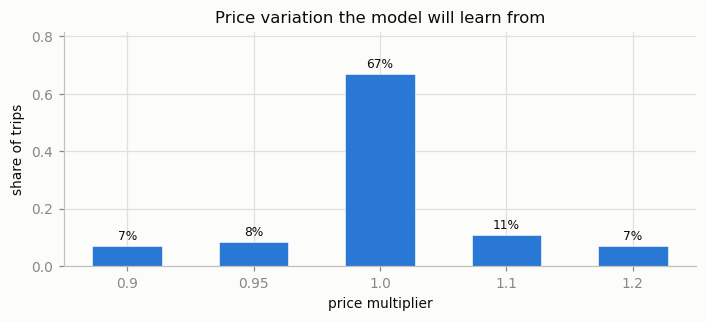

In [9]:

price_share = trips['price_multiplier'].value_counts(normalize=True).sort_index()

fig, ax = plt.subplots(figsize=(6.5, 3))
bars = ax.bar(price_share.index.astype(str), price_share.values, width=0.55,
              color=ACCENT, edgecolor=SURFACE, linewidth=0.4)
for b, v in zip(bars, price_share.values):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.012, f'{v:.0%}',
            ha='center', va='bottom', fontsize=8, color=INK)
ax.set_ylim(0, price_share.max() * 1.22)
ax.set_xlabel('price multiplier')
ax.set_ylabel('share of trips')
ax.set_title('Price variation the model will learn from')
plt.tight_layout()
plt.show()


## 5 · Behavioral State

**Purpose:** Draws each trip's behavioral outcome from a multinomial logit driven by price and latent sensitivity, built with three deliberate structural choices that make the label-reconstruction problem genuinely hard rather than trivial.

**Design Notes:**

- Multinomial logit over five states; `unchanged` is the reference
- Utilities move with `sensitivity × log(price multiplier)`
  1. Price up → probability shifts toward leaving, substituting, reducing
  2. Price down → probability shifts toward increasing
- Three structural choices
  1. Leaving is rare (large negative intercept) but expensive: a class-imbalance problem; untreated model under-predicts it, and the simulation understates the downside
  2. Substitution scales with `substitute_ease`: a good alternative → lower price ceiling, regardless of sensitivity
  3. Increasing is only reachable on a discount: nobody buys more because price went up

In [10]:

STATES = ['leaves', 'substitutes', 'reduces', 'unchanged', 'increases']

def state_probabilities(trips, accounts):
    a = accounts.set_index('account_id').loc[trips['account_id'].to_numpy()]
    sens = a['price_sensitivity'].to_numpy()          # negative
    is_business = a['is_business'].to_numpy()
    tenure = a['tenure_months'].to_numpy()

    logp = np.log(trips['price_multiplier'].to_numpy())   # >0 increase, <0 discount
    ease = trips['substitute_ease'].to_numpy()
    party = trips['lines_traveling'].to_numpy()

    # 0 for solo travelers; rises with party size as the per-head rate falls.
    eff_price_relief = 1.0 - (PRICE_FIRST_LINE + PRICE_ADDL_LINE * (party - 1)) / (PRICE_FIRST_LINE * party)

    u_unchanged = np.zeros(len(trips))

    u_leaves = (
        -5.20
        + (-sens) * 1.10 * logp
        - 0.55 * is_business
        - 0.004 * tenure
    )

    u_substitutes = (
        -2.60
        + (-sens) * 1.85 * logp
        + 1.30 * ease
        - 0.70 * is_business
    )

    u_reduces = (
        -1.90
        + (-sens) * 1.55 * logp
        + 0.45 * ease
        - 0.40 * is_business
        - 0.80 * eff_price_relief
    )

    # Only reachable when logp < 0
    u_increases = (
        -2.40
        + (-sens) * 2.10 * (-np.minimum(logp, 0))
        - 3.00 * np.maximum(logp, 0)
    )

    U = np.column_stack([u_leaves, u_substitutes, u_reduces, u_unchanged, u_increases])
    U = U - U.max(axis=1, keepdims=True)
    P = np.exp(U)
    return P / P.sum(axis=1, keepdims=True)


P = state_probabilities(trips, accounts)
drawn = np.array([RNG.choice(5, p=row) for row in P]) if len(P) < 5_000 else (
    (P.cumsum(axis=1) < RNG.random((len(P), 1))).sum(axis=1)
)
trips['state'] = [STATES[i] for i in drawn]

print(trips['state'].value_counts(normalize=True).round(4))


state
unchanged      0.7287
reduces        0.1113
substitutes    0.0930
increases      0.0645
leaves         0.0024
Name: proportion, dtype: float64


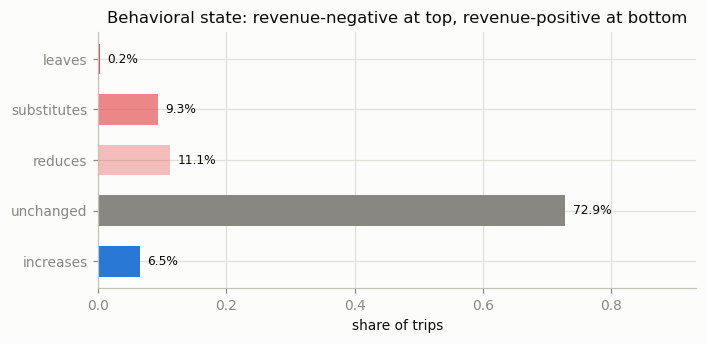

In [11]:
# Diverging: red shades for loss states by severity, gray for neutral, blue for gain.

STATE_ORDER = ['leaves', 'substitutes', 'reduces', 'unchanged', 'increases']
STATE_STYLE = {
    'leaves':      dict(color=RED, alpha=1.00),
    'substitutes': dict(color=RED, alpha=0.65),
    'reduces':     dict(color=RED, alpha=0.35),
    'unchanged':   dict(color=MUTED, alpha=1.00),
    'increases':   dict(color=ACCENT, alpha=1.00),
}

state_share = trips['state'].value_counts(normalize=True).reindex(STATE_ORDER)

fig, ax = plt.subplots(figsize=(6.5, 3.2))
y = np.arange(len(STATE_ORDER))
for yi, s in zip(y, STATE_ORDER):
    ax.barh(yi, state_share[s], height=0.6, **STATE_STYLE[s])
    ax.text(state_share[s] + 0.012, yi, f'{state_share[s]:.1%}',
            va='center', fontsize=8, color=INK)
ax.set_yticks(y)
ax.set_yticklabels(STATE_ORDER)
ax.invert_yaxis()
ax.set_xlim(0, state_share.max() * 1.28)
ax.set_xlabel('share of trips')
ax.set_title('Behavioral state: revenue-negative at top, revenue-positive at bottom')
plt.tight_layout()
plt.show()


## 6 · Magnitude

**Purpose:** Sizes the two price-responsive states (reduce, increase), so a bigger price move produces a deeper behavioral change, not just more people changing.

**Design Notes:**

- Three states are self-sizing: `unchanged` = full coverage; `substitutes`/`leaves` = zero
- The two price-responsive states can move on both day count and line count (a household can share one line)
- Unchanged is not exactly full coverage
  1. Incidental shortfall: late arrival, hotel wifi, forgot to activate
  2. Deliberate: without it, the reduce-vs-unchanged boundary would be trivially separable

In [12]:

def make_magnitudes(trips, accounts, rng):
    n = len(trips)
    state = trips['state'].to_numpy()
    days_t = trips['days_traveled'].to_numpy()
    lines_t = trips['lines_traveling'].to_numpy()
    logp = np.log(trips['price_multiplier'].to_numpy())
    # Cap on lines an account can activate (used below for 'increases').
    lines_cap = accounts.set_index('account_id').loc[trips['account_id'].to_numpy(), 'lines_on_account'].to_numpy()

    days_bought = days_t.copy().astype(float)
    lines_active = lines_t.copy().astype(float)

    # --- reduces: keep the pass, buy less of it ---
    m = state == 'reduces'
    # Deeper cuts at higher prices: Beta mean shifts down as logp rises
    mean_share = np.clip(0.55 - 1.20 * logp[m], 0.10, 0.85)
    conc = 6.0
    share = rng.beta(mean_share * conc, (1 - mean_share) * conc)
    days_bought[m] = np.maximum(np.round(days_t[m] * share), 1)
    # Some of the reduction comes out of lines instead of days
    drop_line = (rng.random(m.sum()) < 0.35) & (lines_t[m] > 1)
    la = lines_active[m]
    la[drop_line] = np.maximum(np.round(la[drop_line] * rng.uniform(0.4, 0.8, drop_line.sum())), 1)
    lines_active[m] = la

    # --- increases: buy more days, occasionally add a line ---
    m = state == 'increases'
    # Floor at 1 extra day; depth still varies with the size of the discount.
    extra = 1 + rng.poisson(np.clip(-12.0 * logp[m], 0.05, 4.0))
    days_bought[m] = days_t[m] + extra
    add_line = (rng.random(m.sum()) < 0.25)
    la = lines_active[m]
    cap = lines_cap[m]
    # Cap at the account's total lines; can't activate more than exist.
    la[add_line] = np.minimum(la[add_line] + 1, cap[add_line])
    lines_active[m] = la

    # --- unchanged: incidental shortfall, not a price response ---
    # Incidental shortfall: late arrival, wifi leg, forgot to activate.
    m = state == 'unchanged'
    incidental = (rng.random(m.sum()) < 0.12) & (days_t[m] >= 3)
    db = days_bought[m]
    # Mostly one day short, occasionally two.
    lost = np.where(rng.random(incidental.sum()) < 0.20, 2, 1)
    db[incidental] = np.maximum(db[incidental] - lost, 1)
    days_bought[m] = db

    # --- no purchase ---
    m = np.isin(state, ['substitutes', 'leaves'])
    days_bought[m] = 0
    lines_active[m] = 0

    out = trips.copy()
    out['days_bought'] = days_bought.astype(int)
    out['lines_active'] = lines_active.astype(int)
    return out


trips = make_magnitudes(trips, accounts, RNG)
trips.groupby('state')[['days_traveled', 'days_bought', 'lines_traveling', 'lines_active']].mean().round(2)


,days_traveled,days_bought,lines_traveling,lines_active
state,,,,
increases,5.43,6.64,1.39,1.54
leaves,5.60,0.00,1.42,0.00
reduces,5.67,3.04,1.36,1.28
substitutes,5.99,0.00,1.45,0.00
unchanged,5.40,5.27,1.41,1.41


## 7 · Revenue

**Purpose:** Applies the pricing identity to what was actually bought, and books a lost account as the value of the whole relationship rather than a single zero-revenue trip.

**Design Notes:**

- Pricing identity applied to what was actually bought:

```
revenue = (price_first_line + price_addl_line × (lines_active − 1)) × days_bought
```

- `leaves` recorded separately, not as zero-revenue
  1. Account-level loss attached here, left for the revenue model to weight

In [13]:

def compute_revenue(trips):
    out = trips.copy()
    active = out['lines_active'].to_numpy()
    rev = np.where(
        active > 0,
        (out['price_first_line'].to_numpy() + out['price_addl_line'].to_numpy() * (active - 1))
        * out['days_bought'].to_numpy(),
        0.0,
    )
    out['pass_revenue'] = rev
    out['account_lost'] = (out['state'] == 'leaves').astype(int)
    return out


trips = compute_revenue(trips)

print(f'Total pass revenue: ${trips.pass_revenue.sum():,.0f}')
print(f'Accounts lost:      {trips.account_lost.sum():,}')
trips.groupby('state')['pass_revenue'].agg(['count', 'sum', 'mean']).round(2)


Total pass revenue: $5,391,476
Accounts lost:      226


,count,sum,mean
state,,,
increases,6102,518603.25,84.99
leaves,226,0.00,0.00
reduces,10530,371685.50,35.30
substitutes,8797,0.00,0.00
unchanged,68924,4501187.50,65.31


## 8 · Sanity Checks

**Purpose:** Confirms the generator's parameters produced domain-plausible behavior, since anything downstream inherits whatever it got wrong.

**Design Notes:**

- Any failure below → parameters are wrong, nothing downstream is worth fitting
  1. Revenue per trip moves coherently with price; raw and composition-adjusted views agree
  2. Business accounts measurably less sensitive than consumer accounts
  3. Substitution more common where the alternative is easier
  4. Trip volume tracks the macro index

In [14]:

chk = trips.merge(accounts[['account_id', 'is_business']], on='account_id')

print('1 · Revenue per trip by price multiplier: raw, then within segment x region')
raw = chk.groupby('price_multiplier')['pass_revenue'].mean().round(2)
adj = (chk.groupby(['is_business', 'region', 'price_multiplier'])['pass_revenue'].mean()
       .groupby('price_multiplier').mean().round(2))
print(pd.DataFrame({'raw': raw, 'within segment x region': adj}).to_string(), '\n')
print('Expectation: revenue per trip RISES with price if demand is net inelastic in')
print('this range, which is the finding the project is testing for. What must not')
print('happen is the raw and adjusted columns telling different stories, which would')
print('mean the pattern is composition, not response.\n')

print('2 · Share of trips buying nothing, by price and segment')
chk['no_purchase'] = chk['days_bought'].eq(0)
print(chk.pivot_table(index='price_multiplier', columns='is_business',
                      values='no_purchase', aggfunc='mean').round(3), '\n')

print('3 · Substitution rate by region')
print(chk.assign(sub=chk.state.eq('substitutes')).groupby('region')['sub'].mean().round(3), '\n')

print('4 · Correlation of monthly trip volume with macro index')
vol = trips.groupby('month').size().rename('trips').reset_index().merge(macro, on='month')
print(round(vol['trips'].corr(vol['macro_index']), 3))


1 · Revenue per trip by price multiplier: raw, then within segment x region
                    raw  within segment x region
price_multiplier                                
0.90              54.42                    57.16
0.95              55.52                    58.10
1.00              57.14                    59.83
1.10              57.81                    61.81
1.20              58.91                    61.32 

Expectation: revenue per trip RISES with price if demand is net inelastic in
this range, which is the finding the project is testing for. What must not
happen is the raw and adjusted columns telling different stories, which would
mean the pattern is composition, not response.

2 · Share of trips buying nothing, by price and segment
is_business       False  True 
price_multiplier              
0.90              0.102  0.068
0.95              0.111  0.066
1.00              0.119  0.067
1.10              0.166  0.082
1.20              0.216  0.091 

3 · Substitution rate by r

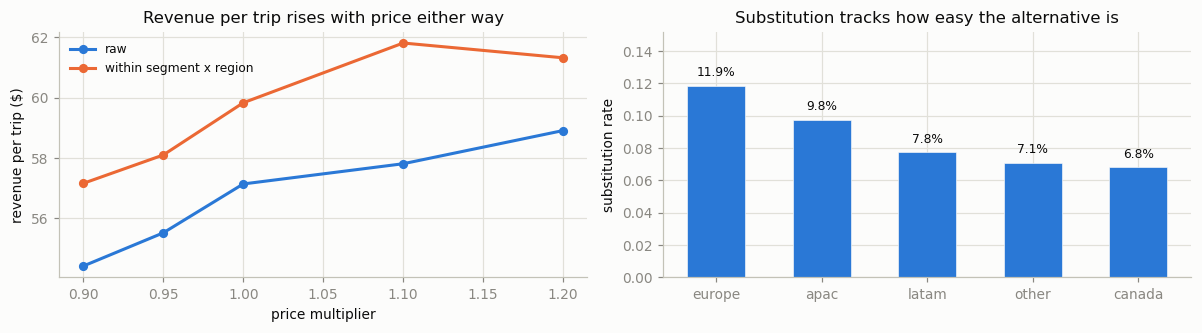

In [15]:

fig, axes = plt.subplots(1, 2, figsize=(11, 3.1))

comp = pd.DataFrame({'raw': raw, 'within segment x region': adj})
axes[0].plot(comp.index, comp['raw'], color=ACCENT, linewidth=2, marker='o', ms=5, label='raw')
axes[0].plot(comp.index, comp['within segment x region'], color=ACCENT2, linewidth=2,
             marker='o', ms=5, label='within segment x region')
axes[0].set_xlabel('price multiplier')
axes[0].set_ylabel('revenue per trip ($)')
axes[0].set_title('Revenue per trip rises with price either way')
axes[0].legend(frameon=False, fontsize=8)

sub_by_region = (chk.assign(sub=chk.state.eq('substitutes'))
                  .groupby('region')['sub'].mean().sort_values(ascending=False))
bars = axes[1].bar(sub_by_region.index, sub_by_region.values, width=0.55,
                    color=ACCENT, edgecolor=SURFACE, linewidth=0.4)
for b, v in zip(bars, sub_by_region.values):
    axes[1].text(b.get_x() + b.get_width() / 2, v + 0.004, f'{v:.1%}',
                 ha='center', va='bottom', fontsize=8, color=INK)
axes[1].set_ylim(0, sub_by_region.max() * 1.28)
axes[1].set_ylabel('substitution rate')
axes[1].set_title('Substitution tracks how easy the alternative is')

plt.tight_layout()
plt.show()


## 9 · Ground Truth

**Purpose:** Exports the true latent sensitivity to a separate file, kept out of the modeling data, so later notebooks can be scored on whether they actually recover the signal rather than just how well they fit.

**Design Notes:**

- Signal provably present but not recovered → the model is the problem, not the data

In [16]:

ground_truth = accounts[['account_id', 'price_sensitivity', 'travel_propensity']].copy()
ground_truth['sensitivity_decile'] = pd.qcut(ground_truth['price_sensitivity'], 10, labels=False)

# Model-facing tables exclude the latent traits
model_accounts = accounts.drop(columns=['price_sensitivity', 'travel_propensity'])

# Prefer parquet; fall back to CSV if pyarrow/fastparquet aren't installed.
try:
    import pyarrow  # noqa: F401
    FMT = 'parquet'
except ImportError:
    try:
        import fastparquet  # noqa: F401
        FMT = 'parquet'
    except ImportError:
        FMT = 'csv'
        print('pyarrow/fastparquet not found, writing CSV instead.')
        print('For smaller files:  pip install pyarrow\n')


def save(df, name):
    path = DATA / f'{name}.{FMT}'
    df.to_parquet(path, index=False) if FMT == 'parquet' else df.to_csv(path, index=False)
    return path


for df, name in [(model_accounts, 'accounts'), (macro, 'macro'),
                 (trips, 'trips'), (ground_truth, 'ground_truth')]:
    save(df, name)

print(f'Written to {DATA.resolve()}')
for f in sorted(DATA.glob(f'*.{FMT}')):
    print(f'  {f.name:24s} {f.stat().st_size/1e6:6.2f} MB')
    

Written to /Users/paforsey/Inbox/Projects/data-science-portfolio/case-studies/international-roaming/research_notebooks/data/synthetic
  account_departure_risk.parquet   0.24 MB
  account_price_response.parquet   1.20 MB
  accounts.parquet           0.39 MB
  deterministic_revenue_curve.parquet   0.00 MB
  ground_truth.parquet       1.32 MB
  macro.parquet              0.00 MB
  magnitude_meta.parquet     0.00 MB
  model_meta.parquet         0.00 MB
  price_sweep.parquet        0.00 MB
  revenue_by_state.parquet   8.69 MB
  scored_trips.parquet       1.87 MB
  simulation_assumptions.parquet   0.00 MB
  simulation_price_sweep.parquet   0.01 MB
  simulation_scenarios.parquet   0.00 MB
  trip_magnitudes.parquet    1.88 MB
  trips.parquet              1.41 MB


---
# Part 2 · Validating the Synthetic Data

- Confirm the generated panel behaves like a plausible telecom population before fitting anything
- Settle the one decision modeling depends on: how to reconstruct the five behavioral states from observables
- Not exploratory in the usual sense: the generating process is known, and every check either validates the generator or produces a number the labeling rule needs
- Three questions
  1. Does the panel look real? Marginals, ratios, revenue concentration in realistic ranges
  2. Is the label boundary readable from the data? Bimodal coverage ratio → threshold reads off the shape
  3. Is there enough price variation to estimate a response, per segment? A segment with no price change can't have its sensitivity estimated
- Failure in (1) → fix parameters in Part 1; failure in (3) → change the price-variation design; neither is recoverable downstream

In [17]:
# Reuse Part 1's in-memory objects; accounts is rebound to model_accounts
# (latent traits dropped) to match what downstream notebooks load from disk.

accounts = model_accounts
trips = trips.merge(accounts, on='account_id', how='left')

print(f'{len(accounts):,} accounts · {len(trips):,} trips · {macro.month.nunique()} months')


50,000 accounts · 94,579 trips · 24 months


---
## 1 · Panel Realism

### 1.1 Coverage & Shape

- Population should not be uniformly active
- Real travel is concentrated: most accounts never travel internationally in a year; a small group travels constantly
- If everyone travels a similar amount, segmentation later has nothing to separate

accounts                                50,000.00
accounts that travelled                 29,406.00
share that travelled                         0.59
trips total                             94,579.00
trips per travelling account (median)        2.00
trips per travelling account (p95)          10.00
months                                      24.00


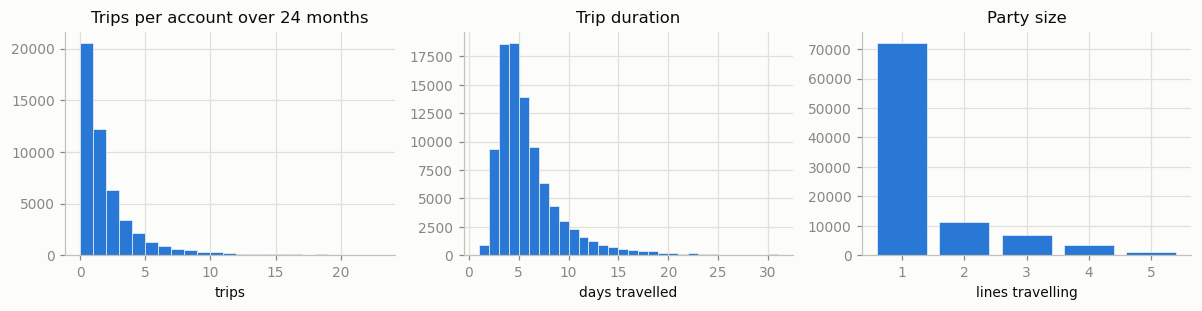

In [18]:

trips_per_account = trips.groupby('account_id').size()
all_accounts = accounts.set_index('account_id').index
trip_counts = trips_per_account.reindex(all_accounts, fill_value=0)

n_months = macro.month.nunique()
summary = pd.Series({
    'accounts': len(accounts),
    'accounts that travelled': (trip_counts > 0).sum(),
    'share that travelled': (trip_counts > 0).mean(),
    'trips total': len(trips),
    'trips per travelling account (median)': trip_counts[trip_counts > 0].median(),
    'trips per travelling account (p95)': trip_counts[trip_counts > 0].quantile(0.95),
    'months': n_months,
})
print(summary.to_string(float_format=lambda v: f'{v:,.2f}'))

fig, axes = plt.subplots(1, 3, figsize=(11, 2.9))

axes[0].hist(trip_counts, bins=range(0, int(trip_counts.quantile(0.995)) + 2),
             color=ACCENT, edgecolor=SURFACE, linewidth=0.4)
axes[0].set_title(f'Trips per account over {n_months} months')
axes[0].set_xlabel('trips')

axes[1].hist(trips['days_traveled'], bins=range(1, 32), color=ACCENT,
             edgecolor=SURFACE, linewidth=0.4)
axes[1].set_title('Trip duration')
axes[1].set_xlabel('days travelled')

party = trips['lines_traveling'].value_counts().sort_index()
axes[2].bar(party.index, party.values, color=ACCENT, edgecolor=SURFACE, linewidth=0.4)
axes[2].set_title('Party size')
axes[2].set_xlabel('lines travelling')

plt.tight_layout()
plt.show()


**Expected Characteristics**

- Large share of accounts with zero trips: international travel is a minority behavior
- Trip duration right-skewed; business trips short, leisure long-tailed
- Party size dominated by 1, with a meaningful household-travel tail (where the `$5` additional-line economics live)
- Symmetric or flat duration/party size → generator parameters need adjusting

### 1.2 Business and Consumer Differentiation

- Entire pricing argument rests on these two groups responding differently
- Indistinguishable in raw data → model has nothing to find, segmentation is noise

Per trip
             trips  accounts  avg_days  avg_party  solo_share  no_purchase_rate  avg_revenue
is_business                                                                                 
consumer     40469     19772     7.217      1.570       0.639             0.129       75.670
business     54110      9634     4.190      1.288       0.857             0.071       43.046

Per account over the full window
             accounts  trips_per_account  revenue_per_account  revenue_p90
is_business                                                               
consumer        19772               2.05               154.88        345.0
business         9634               5.62               241.77        544.0


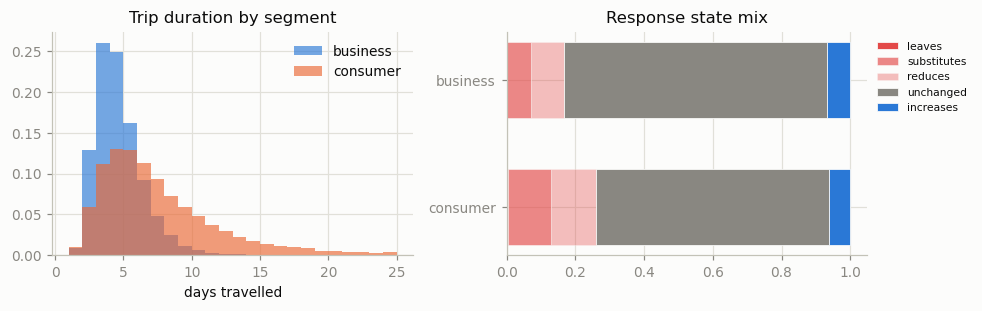

In [19]:

seg = trips.groupby('is_business').agg(
    trips=('trip_id', 'size'),
    accounts=('account_id', 'nunique'),
    avg_days=('days_traveled', 'mean'),
    avg_party=('lines_traveling', 'mean'),
    solo_share=('lines_traveling', lambda s: (s == 1).mean()),
    no_purchase_rate=('days_bought', lambda s: (s == 0).mean()),
    avg_revenue=('pass_revenue', 'mean'),
).round(3)
seg.index = seg.index.map({False: 'consumer', True: 'business'})
print('Per trip')
print(seg.to_string())

# Per account, since business trips are smaller but far more frequent.
per_acct = (trips.groupby(['is_business', 'account_id'])
            .agg(trips=('trip_id', 'size'), revenue=('pass_revenue', 'sum'))
            .groupby('is_business').agg(
                accounts=('trips', 'size'),
                trips_per_account=('trips', 'mean'),
                revenue_per_account=('revenue', 'mean'),
                revenue_p90=('revenue', lambda s: s.quantile(0.90)),
            ).round(2))
per_acct.index = per_acct.index.map({False: 'consumer', True: 'business'})
print('\nPer account over the full window')
print(per_acct.to_string())

fig, axes = plt.subplots(1, 2, figsize=(9, 2.9))

# Two identity series, so categorical slots 1 and 2 (not accent-vs-muted).
for flag, label, color in [(True, 'business', ACCENT), (False, 'consumer', ACCENT2)]:
    sub = trips[trips.is_business == flag]
    axes[0].hist(sub['days_traveled'], bins=range(1, 26), alpha=0.65,
                 label=label, color=color, density=True)
axes[0].set_title('Trip duration by segment')
axes[0].set_xlabel('days travelled')
axes[0].legend(frameon=False)

# Same diverging treatment as the state-mix chart above, for consistency.
STATE_ORDER = ['leaves', 'substitutes', 'reduces', 'unchanged', 'increases']
STATE_COLOR = {'leaves': RED, 'substitutes': RED, 'reduces': RED,
               'unchanged': MUTED, 'increases': ACCENT}
STATE_ALPHA = {'leaves': 1.00, 'substitutes': 0.65, 'reduces': 0.35,
               'unchanged': 1.00, 'increases': 1.00}

state_mix = (trips.groupby('is_business')['state']
             .value_counts(normalize=True).unstack().fillna(0)
             .reindex(columns=STATE_ORDER))
state_mix.index = state_mix.index.map({False: 'consumer', True: 'business'})

left = np.zeros(len(state_mix))
for s in STATE_ORDER:
    axes[1].barh(state_mix.index, state_mix[s], left=left, height=0.6,
                 color=STATE_COLOR[s], alpha=STATE_ALPHA[s],
                 edgecolor=SURFACE, linewidth=0.5, label=s)
    left += state_mix[s].to_numpy()
axes[1].set_title('Response state mix')
axes[1].legend(frameon=False, fontsize=7, bbox_to_anchor=(1.0, 1.0))
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()


### 1.3 Revenue Concentration

- Telecom revenue is heavily concentrated
- Top decile should carry a disproportionate share
- Otherwise: "the opportunity sits in a minority of travellers" would be a generator artefact, not a real finding

top    1% of accounts  ->   11.8% of pass revenue
top    5% of accounts  ->   33.8% of pass revenue
top   10% of accounts  ->   50.7% of pass revenue
top   20% of accounts  ->   72.1% of pass revenue
top   50% of accounts  ->   98.7% of pass revenue


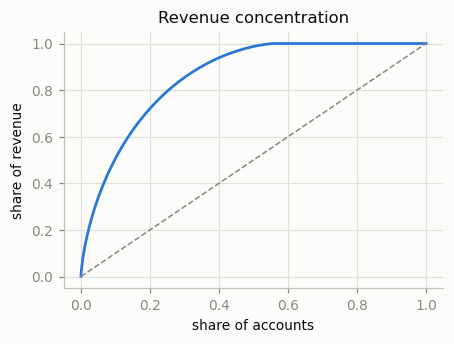

In [20]:

acct_rev = (trips.groupby('account_id')['pass_revenue'].sum()
            .reindex(all_accounts, fill_value=0).sort_values(ascending=False))

cum = acct_rev.cumsum() / acct_rev.sum()
share_of_accounts = np.arange(1, len(cum) + 1) / len(cum)

for pct in [0.01, 0.05, 0.10, 0.20, 0.50]:
    # Guards small populations where pct * len(cum) < 1.
    i = max(int(pct * len(cum)) - 1, 0)
    print(f'top {pct:>5.0%} of accounts  ->  {cum.iloc[i]:>6.1%} of pass revenue')

fig, ax = plt.subplots(figsize=(4.2, 3.2))
ax.plot(share_of_accounts, cum.values, color=ACCENT, linewidth=1.8)
ax.plot([0, 1], [0, 1], color=MUTED, linewidth=1, linestyle='--')
ax.set_xlabel('share of accounts')
ax.set_ylabel('share of revenue')
ax.set_title('Revenue concentration')
plt.tight_layout()
plt.show()


### 1.4 Macro and Seasonality Signal

- Trip volume must track the macro index
- Makes the forward simulation's correlated draws meaningful
- If volume were independent of the economy, modeling macro scenarios later would be theatre

corr(trip volume, macro index)   = 0.758
corr(trip volume, seasonality)   = 0.697
corr(revenue, trip volume)       = 0.998


/var/folders/rj/lg_9h2v52pnckdkdmwvvw3xr0000gn/T/ipykernel_33887/2964094631.py:24: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


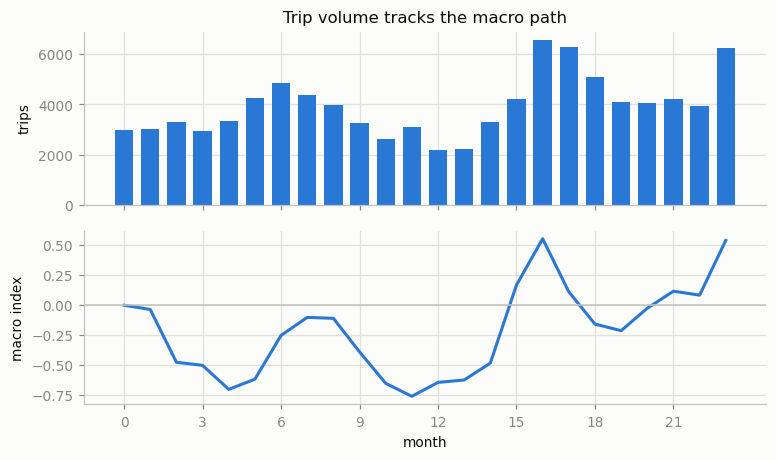

In [21]:

monthly = (trips.groupby('month')
           .agg(trips=('trip_id', 'size'), revenue=('pass_revenue', 'sum'))
           .reset_index().merge(macro, on='month'))

print(f'corr(trip volume, macro index)   = {monthly.trips.corr(monthly.macro_index):.3f}')
print(f'corr(trip volume, seasonality)   = {monthly.trips.corr(monthly.seasonality):.3f}')
print(f'corr(revenue, trip volume)       = {monthly.revenue.corr(monthly.trips):.3f}')

# Two panels sharing an x-axis instead of a dual-axis chart, which would
# imply a false alignment between two different scales.
fig, axes = plt.subplots(2, 1, figsize=(8, 4.4), sharex=True,
                         gridspec_kw={'height_ratios': [1, 1], 'hspace': 0.15})

axes[0].bar(monthly.month, monthly.trips, color=ACCENT, width=0.7)
axes[0].set_ylabel('trips')
axes[0].set_title('Trip volume tracks the macro path')

axes[1].plot(monthly.month, monthly.macro_index, color=ACCENT, linewidth=2)
axes[1].axhline(0, color=BASELINE, linewidth=1)
axes[1].set_ylabel('macro index')
axes[1].set_xlabel('month')
axes[1].set_xticks(range(0, N_MONTHS, 3))

plt.tight_layout()
plt.show()


---
## 2 · Label Boundary Readability

- Most important decision: in production the five states are not observed
- Must be reconstructed from what is measurable:

| Observable | What it distinguishes |
|---|---|
| `days_bought == 0` | bought nothing: **substitutes** or **leaves** |
| `days_bought / days_traveled` | how much of the trip was covered |
| `lines_active / lines_traveling` | how much of the party was covered |

- Hard boundary: **reduces vs unchanged**. Both bought the pass; the question is how far below full coverage counts as deliberate reduction
- Bimodal coverage ratio (spike at 1.0 + separate spread below) → threshold reads off the valley
- Smooth continuum → no threshold defensible; treat probabilistically instead

Day coverage among trips that bought the pass
count    85556.000
mean         0.943
std          0.214
min          0.050
5%           0.500
25%          1.000
50%          1.000
75%          1.000
95%          1.167
max          7.000

exactly 1.0 : 72.5%
above 1.0   : 7.1%   (bought more days than travelled)
below 1.0   : 20.4%


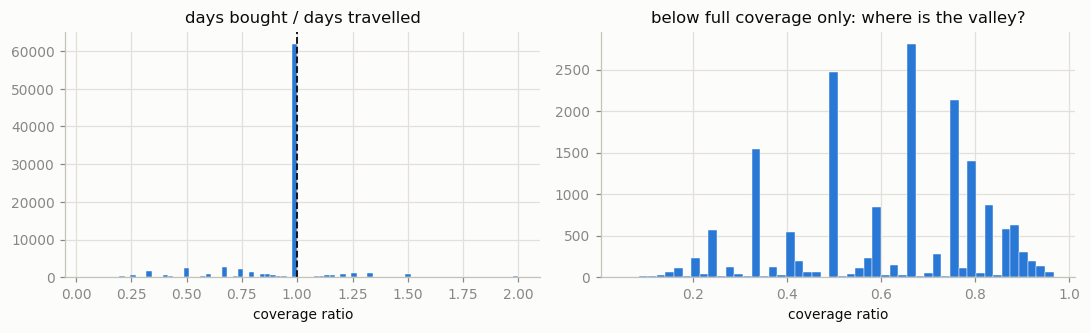

In [22]:

bought = trips[trips['days_bought'] > 0].copy()
bought['day_coverage'] = bought['days_bought'] / bought['days_traveled']
bought['line_coverage'] = bought['lines_active'] / bought['lines_traveling']

print('Day coverage among trips that bought the pass')
print(bought['day_coverage'].describe(percentiles=[.05, .25, .5, .75, .95]).round(3).to_string())
print(f'\nexactly 1.0 : {(bought.day_coverage == 1).mean():.1%}')
print(f'above 1.0   : {(bought.day_coverage > 1).mean():.1%}   (bought more days than travelled)')
print(f'below 1.0   : {(bought.day_coverage < 1).mean():.1%}')

fig, axes = plt.subplots(1, 2, figsize=(10, 3.1))

axes[0].hist(bought['day_coverage'].clip(0, 2), bins=80, color=ACCENT,
             edgecolor=SURFACE, linewidth=0.3)
axes[0].axvline(1.0, color=INK, linewidth=1.2, linestyle='--')
axes[0].set_title('days bought / days travelled')
axes[0].set_xlabel('coverage ratio')

axes[1].hist(bought.loc[bought.day_coverage < 1, 'day_coverage'], bins=50,
             color=ACCENT, edgecolor=SURFACE, linewidth=0.3)
axes[1].set_title('below full coverage only: where is the valley?')
axes[1].set_xlabel('coverage ratio')

plt.tight_layout()
plt.show()


### 2.1 Testing Candidate Thresholds Against the Truth

- Synthetic data → true state is known → can score the labelling rule itself (impossible with real data)
- Each rule applied as it would be in production (observables only), then compared against `state`
- Three rules tested, not one: a coverage ratio alone conflates trip length
  1. 1 day short on a 3-day trip = 0.67 ratio, likely incidental
  2. 1 day short on a 10-day trip = 0.90 ratio, also likely incidental

| Rule | Reduces when |
|---|---|
| **ratio** | coverage falls below a cutoff |
| **absolute** | a fixed number of days went unbought, regardless of trip length |
| **combined** | materially short in days *and* below the ratio cutoff |

- Accuracy is the wrong criterion: `unchanged` dominates, so under-labelling `reduces` still scores well
- F1 on the minority class is the criterion the choice follows

In [23]:

def apply_rule(df, day_thresh, line_thresh=0.999, rule='ratio', days_short=2):
    '''Reconstruct states from observables only; the true state is never used.

    Note: 'substitutes' and 'leaves' are indistinguishable at trip level
    (both simply buy nothing). Separating them requires account-level
    evidence of departure, so they are pooled here as 'no_purchase'.
    '''
    days = df['days_bought'] / df['days_traveled']
    lines = df['lines_active'] / df['lines_traveling'].clip(lower=1)

    short = df['days_traveled'] - df['days_bought']

    if rule == 'ratio':
        is_reduce = days < day_thresh
    elif rule == 'absolute':
        # A fixed number of days short, regardless of trip length
        is_reduce = short >= days_short
    elif rule == 'combined':
        # Must be short in days AND below the ratio cutoff, not just one.
        is_reduce = (short >= days_short) & (days < day_thresh)
    else:
        raise ValueError(rule)

    # no_purchase applied last so it overrides is_reduce for days_bought == 0.
    out = pd.Series('unchanged', index=df.index, dtype=object)
    out[days > 1.0] = 'increases'
    out[is_reduce | (lines < line_thresh)] = 'reduces'
    out[df['days_bought'] == 0] = 'no_purchase'
    return out

truth_pooled = trips['state'].replace({'substitutes': 'no_purchase', 'leaves': 'no_purchase'})

def score(pred, label):
    tp = ((pred == 'reduces') & (truth_pooled == 'reduces')).sum()
    return {
        'rule': label,
        'accuracy': (pred == truth_pooled).mean(),
        'recall': tp / max((truth_pooled == 'reduces').sum(), 1),
        'precision': tp / max((pred == 'reduces').sum(), 1),
        'share labelled': (pred == 'reduces').mean(),
    }

rows, rule_params = [], {}
for t in [0.999, 0.95, 0.90, 0.85, 0.80, 0.70, 0.60, 0.50, 0.40]:
    label = f'ratio < {t}'
    rule_params[label] = dict(day_thresh=t, rule='ratio')
    rows.append(score(apply_rule(trips, t, rule='ratio'), label))
for d in [1, 2, 3, 4]:
    label = f'short >= {d}d'
    rule_params[label] = dict(day_thresh=1.0, rule='absolute', days_short=d)
    rows.append(score(apply_rule(trips, 1.0, rule='absolute', days_short=d), label))
for d in [2, 3]:
    for t in [0.95, 0.85, 0.75]:
        label = f'short >= {d}d and ratio < {t}'
        rule_params[label] = dict(day_thresh=t, rule='combined', days_short=d)
        rows.append(score(apply_rule(trips, t, rule='combined', days_short=d), label))

res = pd.DataFrame(rows).set_index('rule').round(4)
res['f1'] = (2 * res.precision * res.recall / (res.precision + res.recall)).round(4)
print(res.to_string())

true_share = (truth_pooled == 'reduces').mean()
print(f'\nTrue share reducing: {true_share:.4f}')
print(f'Best F1:      {res.f1.idxmax()}  (F1 {res.f1.max():.3f})')
print(f'Best accuracy: {res.accuracy.idxmax()}  ({res.accuracy.max():.1%})')

# Not simply argmax(F1): recall matters more than precision here. Derived
# from rule_params (not hand-typed) and checked against the F1 ranking.
BEST_LABEL = 'ratio < 0.7'
assert BEST_LABEL in res.index, f'{BEST_LABEL!r} not among the candidate rules tested above'
BEST_RULE = rule_params[BEST_LABEL]
best_rank = int(res.f1.rank(ascending=False)[BEST_LABEL])
print(f'\nChosen rule: {BEST_LABEL}  ->  {BEST_RULE}')
print(f"F1 = {res.loc[BEST_LABEL, 'f1']:.3f}, precision = {res.loc[BEST_LABEL, 'precision']:.3f}, "
      f"recall = {res.loc[BEST_LABEL, 'recall']:.3f}  (rank {best_rank} of {len(res)} by F1)")
assert best_rank <= 3, (
    f'{BEST_LABEL!r} dropped to rank {best_rank} by F1, so the asymmetric-cost '
    'argument for choosing it over the top F1 rule no longer holds; re-pick BEST_RULE.'
)

                              accuracy  recall  precision  share labelled      f1
rule                                                                             
ratio < 0.999                   0.9158  0.9513     0.5735          0.1847  0.7156
ratio < 0.95                    0.9165  0.9513     0.5757          0.1840  0.7173
ratio < 0.9                     0.9224  0.9481     0.5950          0.1774  0.7312
ratio < 0.85                    0.9320  0.9342     0.6317          0.1647  0.7537
ratio < 0.8                     0.9453  0.8852     0.7016          0.1405  0.7828
ratio < 0.7                     0.9518  0.7959     0.7770          0.1141  0.7863
ratio < 0.6                     0.9486  0.6048     0.9015          0.0747  0.7239
ratio < 0.5                     0.9273  0.3797     0.9210          0.0459  0.5377
ratio < 0.4                     0.9188  0.3035     0.9031          0.0374  0.4543
short >= 1d                     0.9158  0.9513     0.5735          0.1847  0.7156
short >= 2d     

In [24]:
# Where the chosen rule gets it wrong: the errors matter more than accuracy

pred = apply_rule(trips, **BEST_RULE)
confusion = pd.crosstab(truth_pooled, pred, normalize='index').round(3)
confusion.index.name = 'true state'
confusion.columns.name = 'labelled as'
print(confusion.to_string())


labelled as  increases  no_purchase  reduces  unchanged
true state                                             
increases          1.0          0.0    0.000      0.000
no_purchase        0.0          1.0    0.000      0.000
reduces            0.0          0.0    0.796      0.204
unchanged          0.0          0.0    0.035      0.965


**Reading the Confusion Table**

- Two failure modes, not symmetric
  1. Reduces labelled unchanged → understates price damage; revenue case looks optimistic
  2. Unchanged labelled reduces → overstates damage; recommendation becomes needlessly timid
- Given the decision at stake, the second error is safer
- Threshold chosen accordingly, not purely for accuracy

**On `no_purchase`**

- Substitutes and leaves can't be separated at trip level: both look like no purchase
- Pooled here deliberately
- Splitting requires account-level departure evidence; it belongs in the modelling notebook, not the labelling rule

---
## 3 · Price Variation per Segment

- Price response can only be estimated where price actually moved
- Looks fine overall; frequently fails per segment
- A segment with no variation silently inherits the population average
- Invisible in model metrics: surfaces only when pricing a group the model never had evidence for

In [25]:

print('Overall price exposure')
print(trips['price_multiplier'].value_counts(normalize=True).sort_index().round(4).to_string())
print(f'\nShare of trips off the standard rate: {(trips.price_multiplier != 1.0).mean():.1%}')

trips['party_band'] = pd.cut(trips['lines_traveling'], [0, 1, 2, 10],
                             labels=['solo', 'pair', '3+'])
trips['segment'] = (pd.Series(np.where(trips.is_business, 'business', 'consumer'),
                               index=trips.index)
                      .str.cat(trips.party_band.astype(str), sep=' / '))

variation = trips.pivot_table(index='segment', columns='price_multiplier',
                              values='trip_id', aggfunc='count').fillna(0).astype(int)
variation['total'] = variation.sum(axis=1)
variation['off-standard %'] = (1 - variation[1.0] / variation['total']).round(3)
print('\nTrips by segment and price multiplier')
print(variation.to_string())


Overall price exposure
price_multiplier
0.90    0.0711
0.95    0.0850
1.00    0.6681
1.10    0.1069
1.20    0.0689

Share of trips off the standard rate: 33.2%

Trips by segment and price multiplier
price_multiplier   0.9  0.95    1.0   1.1   1.2  total  off-standard %
segment                                                               
business / 3+      347   418   3305   559   381   5010           0.340
business / pair    196   221   1819   295   189   2720           0.331
business / solo   3312  3937  30988  4946  3197  46380           0.332
consumer / 3+      418   496   4031   651   404   6000           0.328
consumer / pair    628   741   5751   900   592   8612           0.332
consumer / solo   1821  2225  17296  2757  1758  25857           0.331


In [26]:
# Minimum cell size for a segment's response to be estimable at all

MIN_CELL = 300

cells = (trips.groupby(['segment', 'price_multiplier']).size()
         .rename('n').reset_index())
thin = cells[cells.n < MIN_CELL]

if thin.empty:
    print(f'All segment x price cells have at least {MIN_CELL} trips.')
else:
    print(f'Cells below {MIN_CELL} trips (sensitivity here will not be estimable):\n')
    print(thin.sort_values('n').to_string(index=False))

# Does the naive elasticity signal actually appear per segment?
print('\nNo-purchase rate by segment and price: the raw signal the model must find')
signal = trips.pivot_table(index='segment', columns='price_multiplier',
                           values='days_bought', aggfunc=lambda s: (s == 0).mean()).round(3)
print(signal.to_string())


Cells below 300 trips (sensitivity here will not be estimable):

        segment  price_multiplier   n
business / pair              1.20 189
business / pair              0.90 196
business / pair              0.95 221
business / pair              1.10 295

No-purchase rate by segment and price: the raw signal the model must find
price_multiplier   0.90   0.95   1.00   1.10   1.20
segment                                            
business / 3+     0.058  0.057  0.069  0.079  0.081
business / pair   0.046  0.077  0.064  0.085  0.106
business / solo   0.071  0.066  0.067  0.082  0.092
consumer / 3+     0.105  0.125  0.119  0.167  0.225
consumer / pair   0.083  0.108  0.119  0.166  0.191
consumer / solo   0.108  0.109  0.119  0.166  0.222


### 3.1 Intentional Confounding

- Price multiplier assigned by region and period, not at random
- Heavy travellers, specific destinations, and higher-price windows overlap
- Naive comparison would attribute those differences to price
- Check below quantifies how much
- Raw vs. within-segment difference disagreeing → modelling notebook must control for it

In [27]:

high = trips[trips.price_multiplier >= 1.10]
base = trips[trips.price_multiplier == 1.0]

print('Naive comparison, high price vs standard')
print(f'  business share    {high.is_business.mean():.3f}  vs  {base.is_business.mean():.3f}')
print(f"  europe/apac share {high.region.isin(['europe','apac']).mean():.3f}  vs  "
      f"{base.region.isin(['europe','apac']).mean():.3f}")
print(f'  avg days          {high.days_traveled.mean():.2f}  vs  {base.days_traveled.mean():.2f}')

raw = high.days_bought.eq(0).mean() - base.days_bought.eq(0).mean()
print(f'\nRaw difference in no-purchase rate: {raw:+.4f}')

within = []
for (seg_, reg), g in trips.groupby(['segment', 'region']):
    h = g[g.price_multiplier >= 1.10]
    b = g[g.price_multiplier == 1.0]
    if len(h) >= 100 and len(b) >= 100:
        within.append((h.days_bought.eq(0).mean() - b.days_bought.eq(0).mean(), len(h) + len(b)))

if within:
    diffs, weights = zip(*within)
    print(f'Within segment x region:            {np.average(diffs, weights=weights):+.4f}')
    print(f'Confounding accounts for:           {raw - np.average(diffs, weights=weights):+.4f}')
    

Naive comparison, high price vs standard
  business share    0.575  vs  0.571
  europe/apac share 0.880  vs  0.433
  avg days          5.46  vs  5.49

Raw difference in no-purchase rate: +0.0384
Within segment x region:            +0.0220
Confounding accounts for:           +0.0164


---
## 4 · Recovering the Truth

- Final check, only possible with synthetic data: does observed behavior carry the latent sensitivity signal?
- Accounts bucketed by true sensitivity decile, behavior compared
  1. Most/least sensitive deciles behave identically at higher prices → generator needs stronger signal
  2. Clean separation → signal present; a later failure to find it is a modelling problem
- Read value per account, not per trip
  1. Sensitivity correlates with travel frequency; least-sensitive accounts are business, short/solo trips
  2. Per-trip revenue runs inverse to insensitivity, inverting the finding
  3. Any "upside sits with high-value, price-insensitive customers" claim must be made per account

Behaviour at elevated prices, by TRUE sensitivity decile
(decile 0 = most sensitive)

                    trips  no_purchase  avg_coverage  avg_revenue
sensitivity_decile                                               
0                     776        0.205         4.719       70.407
1                     767        0.199         4.857       72.247
2                     861        0.192         5.084       73.454
3                     909        0.188         5.024       72.625
4                     987        0.171         4.879       72.549
5                    1095        0.174         4.828       68.619
6                    1366        0.130         4.739       66.932
7                    1915        0.131         4.049       56.425
8                    3141        0.104         3.583       47.993
9                    4812        0.076         3.629       48.254

Value per account by sensitivity decile: the unit a price decision uses
                    accounts  trips_per_account  

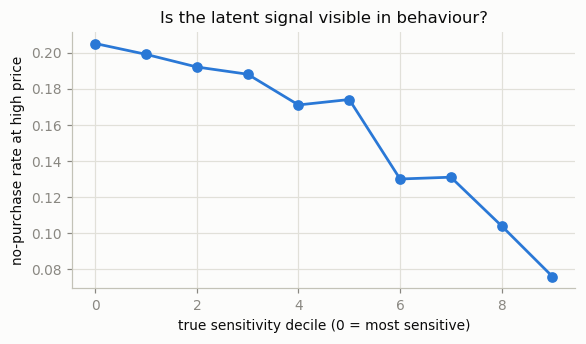


Spread, most vs least sensitive decile: +0.129
Signal is present and learnable.


In [28]:

gt = trips.merge(ground_truth[['account_id', 'sensitivity_decile']], on='account_id')
high_price = gt[gt.price_multiplier >= 1.10]

by_decile = high_price.groupby('sensitivity_decile').agg(
    trips=('trip_id', 'size'),
    no_purchase=('days_bought', lambda s: (s == 0).mean()),
    avg_coverage=('days_bought', 'mean'),
    avg_revenue=('pass_revenue', 'mean'),
).round(3)
print('Behaviour at elevated prices, by TRUE sensitivity decile')
print('(decile 0 = most sensitive)\n')
print(by_decile.to_string())

# Per account (not per trip): uses the full window gt, not just high_price.
acct_decile = (gt.groupby(['sensitivity_decile', 'account_id'])
               .agg(trips=('trip_id', 'size'), revenue=('pass_revenue', 'sum'))
               .groupby('sensitivity_decile').agg(
                   accounts=('trips', 'size'),
                   trips_per_account=('trips', 'mean'),
                   revenue_per_account=('revenue', 'mean'),
               ).round(2))
print('\nValue per account by sensitivity decile: the unit a price decision uses')
print(acct_decile.to_string())

fig, ax = plt.subplots(figsize=(5.4, 3.2))
ax.plot(by_decile.index, by_decile.no_purchase, marker='o', color=ACCENT, linewidth=1.8)
ax.set_xlabel('true sensitivity decile (0 = most sensitive)')
ax.set_ylabel('no-purchase rate at high price')
ax.set_title('Is the latent signal visible in behaviour?')
plt.tight_layout()
plt.show()

spread = by_decile.no_purchase.iloc[0] - by_decile.no_purchase.iloc[-1]
print(f'\nSpread, most vs least sensitive decile: {spread:+.3f}')
print('Signal is present and learnable.' if abs(spread) > 0.05
      else 'Signal too weak; increase sensitivity dispersion in Part 1 above.')
